# Creating subsets of ABCD subjects for expert raters

This is for GE and Philips 

In [2]:
import pandas as pd
import numpy as np

whole_qc_df = pd.read_parquet("/Users/stevenmeisler/Documents/Penn/abcc-qsiprep/paper_code/merged_data_11172025_with_predictions.parquet")
print(whole_qc_df.shape)

(29561, 4337)


In [3]:
whole_qc_df = whole_qc_df[whole_qc_df.raw_num_directions > 101]
total_participants_original = whole_qc_df.shape[0]
print(whole_qc_df.shape)

(25998, 4337)


## CuBIDS acquisition groups

We know that many different scanners (and even operating systems within scanners) were used to collect ABCD. We have a CuBIDS csv with all the acquisition groupings listed:

How common are the different diffusion acquisitions?

In [4]:
# Get number of participants per manufacturer
print("Number of participants per manufacturer \n",whole_qc_df["Manufacturer"].value_counts())
# Ger number of participants per session
print("Number of participants per session \n",whole_qc_df["session_id"].value_counts())

Number of participants per manufacturer 
 Manufacturer
Siemens    16305
GE          6859
Philips     2815
Name: count, dtype: int64
Number of participants per session 
 session_id
ses-00A    8981
ses-02A    7286
ses-04A    6061
ses-06A    3670
Name: count, dtype: int64


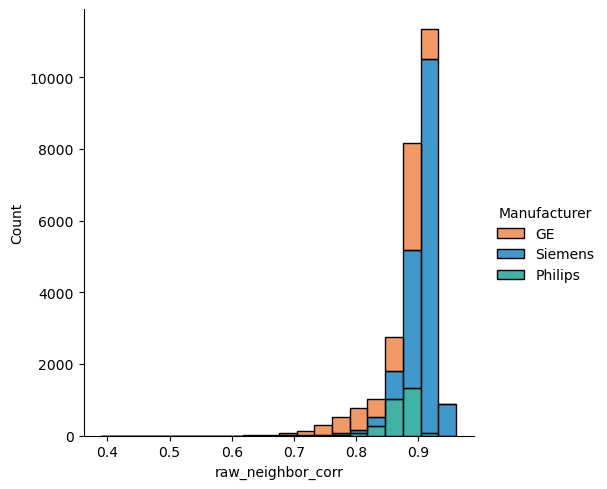

In [5]:
import seaborn as sns
SCANNER_COLORS = {
    "Siemens": "#0077BB",
    "GE": "#EE7733",
    "Philips": "#009988"
}
sns.displot(
    data=whole_qc_df,
    x="raw_neighbor_corr",
    hue="Manufacturer",
    stat="count",
    multiple="stack",
    palette=SCANNER_COLORS,
    legend=True,
    bins=20
)


In [6]:
whole_qc_df['ManufacturerNDCRank'] = whole_qc_df.groupby("Manufacturer")[
    "raw_neighbor_corr"].rank(pct=True)
whole_qc_df = whole_qc_df[np.isfinite(whole_qc_df.ManufacturerNDCRank)]


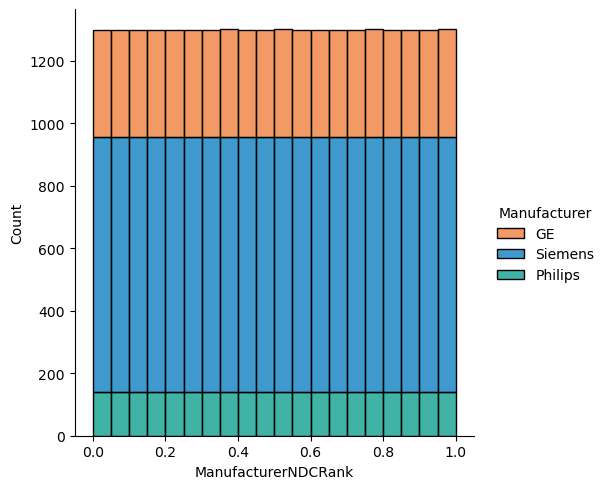

In [8]:
sns.displot(
    data=whole_qc_df, 
    x='ManufacturerNDCRank', 
    hue="Manufacturer", 
    stat='count', 
    multiple='stack', 
    palette=SCANNER_COLORS,
    legend = True, bins=20)

In [9]:
def bin_percentiles(num_bins=10):
     return np.ceil(whole_qc_df["ManufacturerNDCRank"] * num_bins).astype(np.int32)

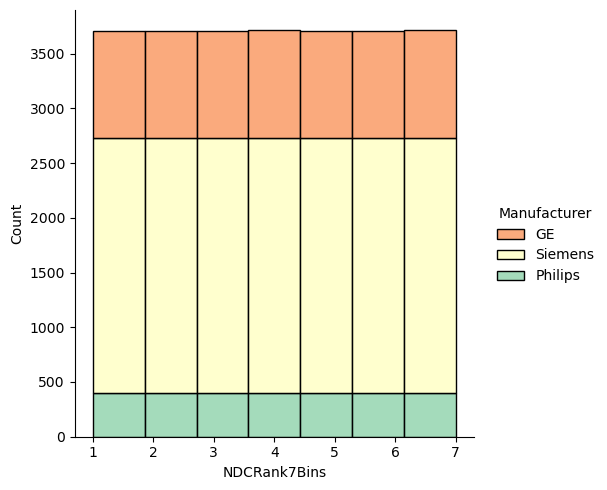

In [10]:
whole_qc_df['NDCRank7Bins'] = bin_percentiles(7)
whole_qc_df['NDCRank10Bins'] = bin_percentiles(10)
whole_qc_df['NDCRank5Bins'] = bin_percentiles(5)
sns.displot(
    data=whole_qc_df, 
    x='NDCRank7Bins', 
    hue="Manufacturer", 
    stat='count', 
    multiple='stack', 
    palette=sns.color_palette("Spectral", 3), 
    legend = True, bins=7);

In [11]:
from collections import defaultdict
from tqdm import tqdm
from random import shuffle
from math import comb
import itertools
import numpy as np
import pandas as pd

def assign_subjects_to_raters(n_raters, n_raters_per_participant, n_ndc_bins, final_min_per_bin=1):
    n_fillers = 0
    # Calculate total participants needed
    total_n_participants = comb(n_raters, n_raters_per_participant)
    half_images = total_n_participants // 2  # Split evenly between "GE" and "Philips"

    # Prepare the rater matchings
    raters = list(range(n_raters))
    rater_combos = list(itertools.combinations(raters, n_raters_per_participant))
    shuffle(rater_combos)
    
    # Prepare the dataset for subsetting
    qc_df = whole_qc_df.copy()
    qc_df["NDCBin"] = bin_percentiles(n_ndc_bins)  # Stratify into bins

    # Create a unique ID for each subject-session combo
    qc_df["SubjectSessionID"] = qc_df["subject_id"].astype(str) + "_" + qc_df["session_id"].astype(str)

    # Split dataset by manufacturer
    ge_data = qc_df[qc_df["Manufacturer"] == "GE"]
    philips_data = qc_df[qc_df["Manufacturer"] == "Philips"]

    # Calculate bin-wise minima for GE and Philips
    def calculate_bin_minima(data, n_bins, total_samples):
        return {bin_: total_samples // n_bins for bin_ in range(1, n_bins + 1)}

    ge_minima = calculate_bin_minima(ge_data, n_ndc_bins, half_images)
    philips_minima = calculate_bin_minima(philips_data, n_ndc_bins, half_images)

    # Prepare for assignments
    selected_subjects = []
    rater_assignments = {rater: {key: [] for key in itertools.product(["GE", "Philips"], range(1, n_ndc_bins + 1))} for rater in raters}
    bin_assignments = pd.DataFrame(
        np.zeros((len(raters), 2 * n_ndc_bins)),  # Columns for "GE" and "Philips" bins
        index=raters, 
        columns=[f"{manufacturer}_{bin_}" for manufacturer in ["GE", "Philips"] for bin_ in range(1, n_ndc_bins + 1)]
    )
    needs_assignment = []

    def assign_to_rater(rater_id, subject_session_id, manufacturer, ndcbin):
        rater_assignments[rater_id][(manufacturer, ndcbin)].append(subject_session_id)
        col = f"{manufacturer}_{ndcbin}"
        bin_assignments.loc[rater_id, col] += 1
        selected_subjects.append(subject_session_id)

    # Assign participants for each manufacturer
    for manufacturer, data, minima in [("GE", ge_data, ge_minima), ("Philips", philips_data, philips_minima)]:
        counts_df = data[["Manufacturer", "NDCBin"]].value_counts().reset_index()
        counts_df.columns = ["Manufacturer", "NDCBin", "NParticipants"]
        counts_df.sort_values(["Manufacturer", "NDCBin"], inplace=True)

        for ndcbin, ndcbin_df in data.groupby("NDCBin"):
            # Sample participants per bin
            inbin_subjects = ndcbin_df.sample(n=minima[ndcbin], replace=False)
            
            for subid, sessionid in zip(inbin_subjects['subject_id'], inbin_subjects['session_id']):
                subject_session_id = f"{subid}_{sessionid}"  # Unique identifier for subject-session combo
                if len(rater_combos):
                    for rater_id in rater_combos.pop():
                        assign_to_rater(rater_id, subject_session_id, manufacturer, ndcbin)
                else:
                    needs_assignment.append((manufacturer, ndcbin, subject_session_id))
    
    # Handle leftover assignments
    rater_combos = list(itertools.combinations(raters, n_raters_per_participant))
    shuffle(rater_combos)
    for (manufacturer, ndcbin, subject_session_id) in needs_assignment:
        for rater_id in rater_combos.pop():
            assign_to_rater(rater_id, subject_session_id, manufacturer, ndcbin)

    # Ensure minimum per bin
    if bin_assignments.min().min() < final_min_per_bin:
        needed_rows, needed_cols = np.nonzero((bin_assignments < final_min_per_bin).to_numpy())
        n_fillers = len(needed_rows)
        for needed_row, needed_col in zip(needed_rows, needed_cols):
            unassigned_subjects = qc_df[
                ~qc_df["SubjectSessionID"].isin(selected_subjects)]
            rater_id = raters[needed_row]
            mfg, binn = bin_assignments.columns[needed_col].split("_")
            binn = int(binn)
            available_data = unassigned_subjects[
                (unassigned_subjects["Manufacturer"] == mfg) & (unassigned_subjects["NDCBin"] == binn)]
            subject_session_id = available_data['SubjectSessionID'].tolist()[0]
            assign_to_rater(rater_id, subject_session_id, mfg, binn)
    
    return bin_assignments, rater_assignments, n_fillers


In [12]:
n_raters = 21
best_n_fillers = 100
best_bin_assignments = None
best_rater_assignments = None
bin_assignments, rater_assignments, n_fillers = assign_subjects_to_raters(n_raters, 3, 7, 2)
#np.save("rater_assignments.npy", rater_assignments)

In [ ]:
#rater_assignments = np.load("rater_assignments.npy", allow_pickle=True).item()

Now that we know things are stratified we can double-check that all the balancing has worked

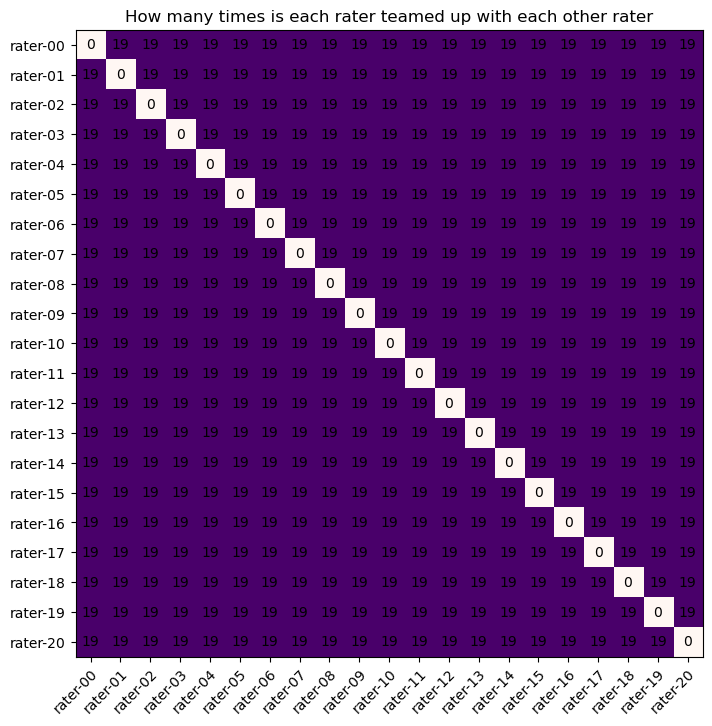

In [13]:
from collections import defaultdict
import itertools
import numpy as np
from matplotlib import pyplot as plt

# Assuming `rater_assignments` is already created as per the previous code.
sub_to_rater = defaultdict(list)
rater_to_sub = defaultdict(list)

# Update the loop to use `subject_session_id` (subject_id_session_id)
for rater, binned_assignments in rater_assignments.items():
    for binname, subids in binned_assignments.items():
        for subid in subids:
            # Create subject_session_id for each subject-session combo
            subject_session_id = f"{subid}_{subid.split('_')[-1]}"  # Assuming the format is subject_id_session_id
            rater_to_sub[rater].append(subject_session_id)
            sub_to_rater[subject_session_id].append(rater)

# Initialize the rater pairing matrix
irr_matrix = np.zeros((n_raters, n_raters))

# Iterate through the subject-session IDs and count how many times raters are paired
for subject_session_id, rater_combo in sub_to_rater.items():
    for pair in itertools.permutations(rater_combo, 2):
        irr_matrix[pair] += 1

# Plotting the heatmap of how many times raters are teamed up with each other
fig, ax = plt.subplots(figsize=(7, 7))
fig.tight_layout()

im = ax.imshow(irr_matrix, cmap="RdPu")

# Show all ticks and label them with the respective list entries
raters = ["rater-%02d" % raternum for raternum in range(n_raters)]
ax.set_xticks(np.arange(len(raters)), labels=raters)
ax.set_yticks(np.arange(len(raters)), labels=raters)

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations
for i in range(len(raters)):
    for j in range(len(raters)):
        text = ax.text(j, i, int(irr_matrix[i, j]), ha="center", va="center", color="k")

_ = ax.set_title("How many times is each rater teamed up with each other rater")
plt.show()